# Overview

Implementing Machine and Deep Learning Algorithms from Scratch. In this notebook, we'll be implementing Support Vector Machine Classification algorithm from scratch.

For this task we'll use the [Iris Species Dataset](https://www.kaggle.com/datasets/uciml/iris).

<img src="https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEimmGMPw0jM_8xjndEHLKj7Hf5fngvWFOJ6_V4jiFb-U0sCHej3aTu08htye1_BgUBGKfnszHoeI_OLLZVf6NjwaG9oDYyOqkjdjeDajd3zg8VuCLVTzDM8hO2XEnarwQeM-CLvFgAwfNX53GR_HPatNPkUH7-7FAoNgFKjw7ujB9LwW5piE8GIPLjJHw/s722/irir_flowers.png">

# Imports

In [1]:
import pandas as pd # for data processing
import numpy as np # for linear algebra
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load the dataset

In [2]:
data = pd.read_csv("/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")

# Exploratory Data Analysis

In [3]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
data.drop("Id", axis=1, inplace=True)

In [5]:
data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


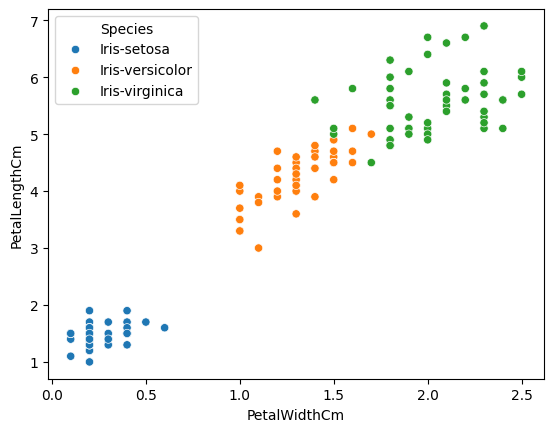

In [7]:
sns.scatterplot(x=data["PetalWidthCm"], y=data["PetalLengthCm"], hue=data["Species"])
plt.show()

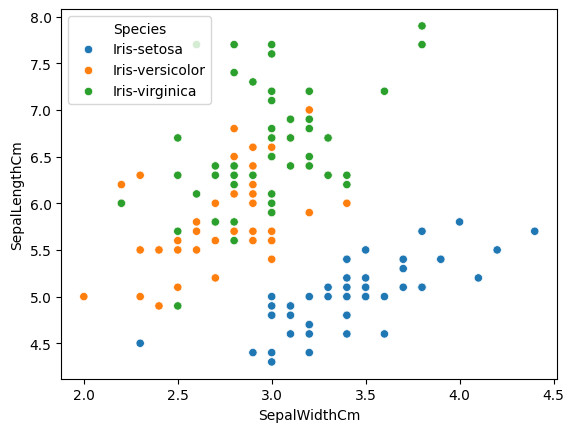

In [8]:
sns.scatterplot(x=data["SepalWidthCm"], y=data["SepalLengthCm"], hue=data["Species"])
plt.show()

## Class Distribution

In [9]:
data.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

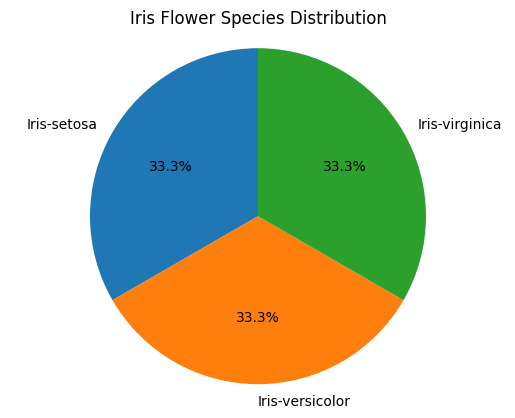

In [10]:
n_iris_setosa = data.Species.loc[data.Species=="Iris-setosa"].count()
n_iris_versicolor = data.Species.loc[data.Species=="Iris-versicolor"].count()
n_iris_virgininca = data.Species.loc[data.Species=="Iris-virginica"].count()

plt.pie([n_iris_setosa, n_iris_versicolor, n_iris_virgininca], labels=["Iris-setosa", "Iris-versicolor", "Iris-virginica"], autopct='%1.1f%%', startangle=90)
plt.title("Iris Flower Species Distribution")
plt.axis('equal')
plt.show()

In [11]:
# Reassign target values
data["Species"] = data["Species"].map({"Iris-setosa": 0, "Iris-versicolor": 1, "Iris-virginica": 2})
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## Correlation Map

In [12]:
data.corr()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954,0.782561
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757,0.949043
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000,0.956464
Species,0.782561,-0.419446,0.949043,0.956464,1.000000


> Petal Length and Petal Width are the most influential features.

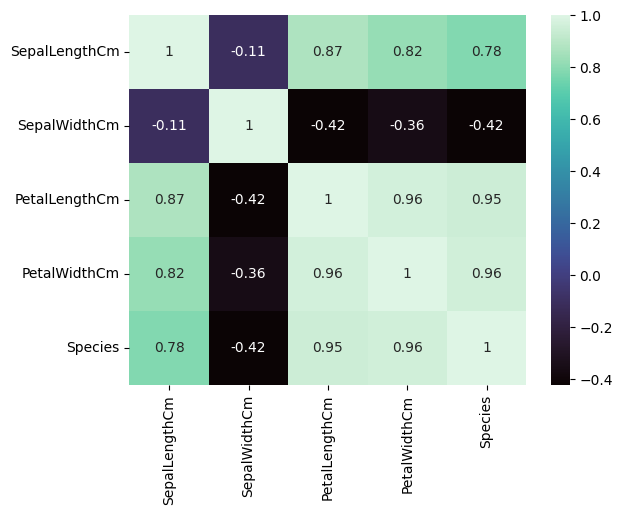

In [13]:
sns.heatmap(data.corr(), annot=True, cmap="mako")
plt.show()

## Splitting the dataset

In [14]:
X_data = data.iloc[:, :-1]
y_data = data.iloc[:, -1]

## Normalization

In [15]:
def scaler(X):
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X

In [16]:
X_data = scaler(X_data)

In [17]:
X_train, X_test_df, y_train, y_test_df = train_test_split(X_data, y_data, test_size = 0.2, random_state=42, stratify=y_data)

In [18]:
# Splitting the dataset for One-vs-One approach & features and the target label
X_train0 = X_train.loc[y_train.isin([0, 1])].values
y_train0 = y_train.loc[y_train.isin([0, 1])].values
X_train1 = X_train.loc[y_train.isin([0, 2])].values
y_train1 = y_train.loc[y_train.isin([0, 2])].values
X_train2 = X_train.loc[y_train.isin([1, 2])].values
y_train2 = y_train.loc[y_train.isin([1, 2])]
y_train2 = y_train2.map({1: 0, 2: 1}).values

X_test = X_test_df.values
y_test = y_test_df.values

In [19]:
print("X_train0: ",X_train0.shape)
print("y_train0: ",y_train0.shape)
print("X_train1: ",X_train1.shape)
print("y_train1: ",y_train1.shape)
print("X_train2: ",X_train2.shape)
print("y_train2: ",y_train2.shape)
print("X_test: ",X_test.shape)
print("y_test: ",y_test.shape)

X_train0:  (80, 4)
y_train0:  (80,)
X_train1:  (80, 4)
y_train1:  (80,)
X_train2:  (80, 4)
y_train2:  (80,)
X_test:  (30, 4)
y_test:  (30,)


# SVM Classification Model

A support vector machine (SVM) is a powerful and versatile machine learning model, capable of performing linear or nonlinear classification, regression, and even novelty detection. SVMs shine with small to medium-sized nonlinear datasets (i.e., hundreds to thousands of instances), especially for classification tasks.

<img src="https://towardsdatascience.com/wp-content/uploads/2023/10/1bXlp7LVAPhIay-Pk0MxdlA.png" width=500>

Key Terms:

### Hyperplane
A hyperplane is a decision boundary that separates data points into different classes in a high-dimensional space. In two-dimensional space, a hyperplane is simply a line that separates the data points into two classes. In three-dimensional space, a hyperplane is a plane that separates the data points into two classes.

So the goal of the hyperplane is to maximise the margin between the two classes. The equation of the hyperplane can be represented as: $$wx + b = 0$$

Here,
- w is the weight vector
- x is the feature vector
- b is the bias

To classify data points, we use the following conditions:

- For a data point with label $y = 1$, we want $wx + b \geq 1$
- For a data point with label $y = -1$, we want $wx + b \leq 1$

In general, we aim for: $$y(wx + b) \geq 1$$

### Margin
A margin is the distance between the decision boundary (hyperplane) and the closest data points from each class. The goal of SVMs is to maximize this margin while minimizing classification errors.

### Support Vectors
They are the data points that lie closest to the decision boundary (hyperplane) in a Support Vector Machine (SVM). These data points are important because they determine the position and orientation of the hyperplane.

### Hinge Loss Function for Support Vector Machines
$$ J(w, b) = \lambda\left\lVert w\right\rVert^2 + {1\over n}\sum^n_{i=1} max(0, 1 - y_i(wx_i + b))$$

Now let's see the gradients,

For a data point $x_i$ with label $y_i$ that satisfies $y_i(wx_i + b)\geq1$ (correctly classified and outside the margin) i.e. Non-support vectors, the gradients are: $${\partial J \over \partial w} = 2\lambda w$$
$${\partial J \over \partial b} = 0$$

For a data point $x_i$ with label $y_i$ that does not satisfy $y_i(wx_i + b)\geq1$ (either incorrectly classified or within the margin) i.e. Support vectors, the gradients are: $${\partial J \over \partial w} = 2\lambda w - y_ix_i$$
$${\partial J \over \partial b} = -y_i$$

Here,  
- J is the Hinge cost function of SVM
- $\lambda$ is the regularization parameter (which controls the trade-off between increasing the margin size and ensuring that the $x_i$ lies on the correct side of the margin)
- $x_i$ is the $i^{th}$ data point
- $y_i$ is the corresponding label

This setup ensures that the classifier not only finds a separating hyperplane (if it exists) but also seeks the one that maximizes the margin between classes, which is central to SVM's classification strategy.

In [20]:
class SVC:
    """
    A Support Vector Machine Classifier (SVC) implementation using gradient descent.

    Parameters:
    -----------
    lr : float, default=0.01
        The learning rate for gradient descent.
    _lambda : float, default=0.01
        The regularization parameter.

    Attributes:
    -----------
    _lambda : float
        The regularization parameter.
    lr : float
        The learning rate for gradient descent.
    w : numpy array
        The weights.
    b : float
        The bias.

    Methods:
    --------
    initialize_parameters(X)
        Initializes the weights and bias.
    fit(X, y)
        Fits the SVM to the data.
    predict(X)
        Predicts the labels for the given data.

    """
    def __init__(self, lr=0.01, _lambda=0.01):
        self._lambda = _lambda
        self.lr = lr
        self.W = None
        self.b = None

    def initialize_parameters(self, X):
        """
        Initializes the weights and bias.
        """
        self.W = np.zeros((X.shape[1]))
        self.b = 0

    def hinge_loss(self, X, y):
        """
        Computes the total loss (hinge loss + L2 regularization).
        """
        m = X.shape[0]
        outputs = np.dot(X, self.W) + self.b
        
        # Hinge loss calculation: max(0, 1 - y_i * score_i)
        losses = np.maximum(0, 1 - y * outputs)
        total_hinge_loss = np.sum(losses)
        
        # L2 regularization part: 0.5 * ||W||^2 (C is a scaling factor for the loss term in the objective)
        regularization_loss = self._lambda * np.dot(self.W, self.W)
        
        # Total objective function
        total_loss = regularization_loss + (total_hinge_loss / m)
        
        return total_loss

    def compute_accuracy(self, y_true, y_pred):
        total_samples = len(y_true)
        correct_predictions = np.sum(y_true == y_pred)
        return (correct_predictions / total_samples) 

    def fit(self, X, y, epochs=1000):
        """
        Fits the SVM to the data.

        Parameters:
        -----------
        X : numpy array
            The input data.
        y : numpy array
            The target values.
        epochs: int
                The number of iterations for gradient descent.
        """
        self.initialize_parameters(X)
        y_ = np.where(y <= 0, -1, 1)
        costs = []
        for e in range(epochs+1):
            for i, x in enumerate(X):
                if y_[i] * (np.dot(x, self.W) + self.b) >= 1: # Not in the street(outside the margin)
                    self.dW = 2 * self._lambda * self.W
                    self.db = 0
                else:
                    self.dW = 2 * self._lambda * self.W - y_[i] * x
                    self.db = -y_[i]
                self.W = self.W - self.lr * self.dW
                self.b = self.b - self.lr * self.db
                
            cost = self.hinge_loss(X, y_)
            costs.append(cost)
            y_pred = np.sign(np.dot(X, self.W) + self.b)
            accuracy = self.compute_accuracy(y_, y_pred)
            if e % 100 == 0:
                print(f'Iteration: {e}, Cost: {cost}, Accuracy: {accuracy}')
                
        plt.plot(np.arange(epochs+1), costs)
        plt.title("Cost vs Iterations", fontsize=14)
        plt.xlabel("Iterations", fontsize=12)
        plt.ylabel("Cost", fontsize=12)
        plt.grid(True)
        plt.show()

    def predict(self, X):
        """
        Predicts the class labels for the data.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            The input data.

        Returns
        -------
        label_signs : array-like, shape (n_samples,)
            The predicted class labels.

        """
        # get the outputs
        outputs = np.dot(X, self.W) + self.b
        # get the signs of the labels
        label_signs = np.where(outputs >= 0, 1, -1)
        return label_signs

    def predict_proba(self, X):
        """
        Predicts the class probabilities for the data.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            The input data.

        Returns
        -------
        proba : array-like, shape (n_samples,)
            The predicted class labels.

        """
        # get the outputs
        proba = np.dot(X, self.W) + self.b
        return proba

Iteration: 0, Cost: 0.20512697029340757, Accuracy: 1.0
Iteration: 100, Cost: 0.018107837025637695, Accuracy: 1.0
Iteration: 200, Cost: 0.018333330996688345, Accuracy: 1.0
Iteration: 300, Cost: 0.01785321488852158, Accuracy: 1.0
Iteration: 400, Cost: 0.01805536888679743, Accuracy: 1.0
Iteration: 500, Cost: 0.018014410337382245, Accuracy: 1.0
Iteration: 600, Cost: 0.018154653044686254, Accuracy: 1.0
Iteration: 700, Cost: 0.017830208461855637, Accuracy: 1.0
Iteration: 800, Cost: 0.017838482657529315, Accuracy: 1.0
Iteration: 900, Cost: 0.017887360015031353, Accuracy: 1.0
Iteration: 1000, Cost: 0.017922919122898395, Accuracy: 1.0


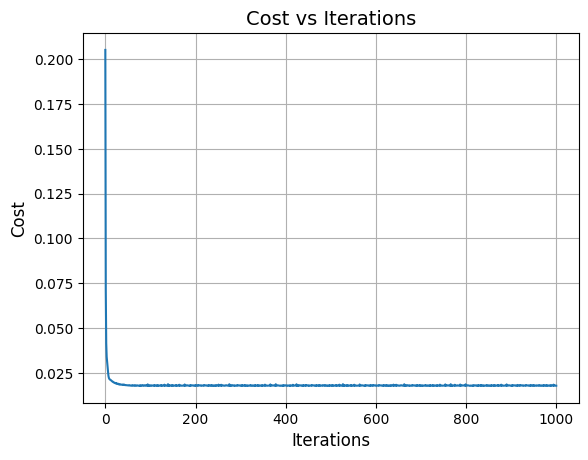

In [21]:
model0 = SVC()
model0.fit(X_train0, y_train0)

Iteration: 0, Cost: 0.027770590299149342, Accuracy: 1.0
Iteration: 100, Cost: 0.006925240300678549, Accuracy: 1.0
Iteration: 200, Cost: 0.00668135073881526, Accuracy: 1.0
Iteration: 300, Cost: 0.006786835588519568, Accuracy: 1.0
Iteration: 400, Cost: 0.006551154463500348, Accuracy: 1.0
Iteration: 500, Cost: 0.006651705683851556, Accuracy: 1.0
Iteration: 600, Cost: 0.006619978651442961, Accuracy: 1.0
Iteration: 700, Cost: 0.006983558242980848, Accuracy: 1.0
Iteration: 800, Cost: 0.006618751772459637, Accuracy: 1.0
Iteration: 900, Cost: 0.006691721963647063, Accuracy: 1.0
Iteration: 1000, Cost: 0.006676793266405047, Accuracy: 1.0


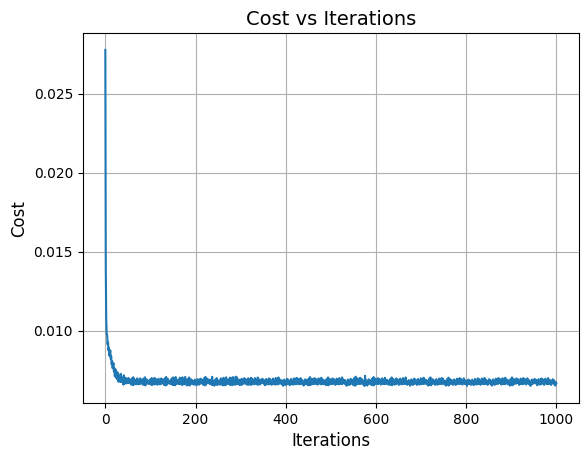

In [22]:
model1 = SVC()
model1.fit(X_train1, y_train1)

### Using polynomial features for this model (Versicolor vs Virginica)

Iteration: 0, Cost: 0.2523333490267055, Accuracy: 0.925
Iteration: 100, Cost: 0.09486328891771038, Accuracy: 0.975
Iteration: 200, Cost: 0.09513608303570802, Accuracy: 0.975
Iteration: 300, Cost: 0.09493099485756532, Accuracy: 0.975
Iteration: 400, Cost: 0.09560904641000134, Accuracy: 0.975
Iteration: 500, Cost: 0.09531995247973929, Accuracy: 0.975
Iteration: 600, Cost: 0.09438216944170912, Accuracy: 0.9875
Iteration: 700, Cost: 0.09510524554175373, Accuracy: 0.975
Iteration: 800, Cost: 0.09529707680689613, Accuracy: 0.975
Iteration: 900, Cost: 0.09482660563443375, Accuracy: 0.975
Iteration: 1000, Cost: 0.09431606110736665, Accuracy: 0.975


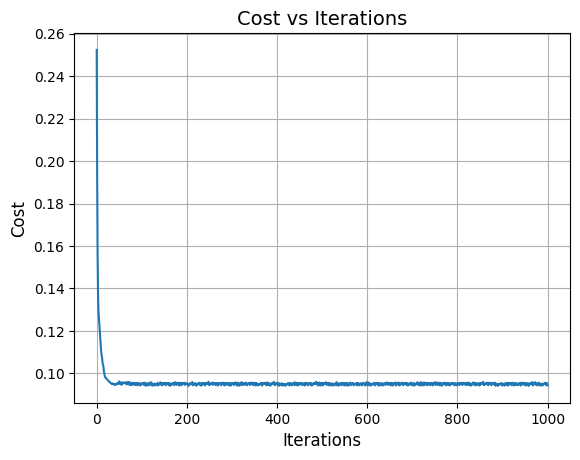

In [23]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train2_poly = poly.fit_transform(X_train2)

poly_mean = X_train2_poly.mean(axis=0)
poly_std = X_train2_poly.std(axis=0)

X_train2_poly = (X_train2_poly - poly_mean) / poly_std

model2 = SVC()
model2.fit(X_train2_poly, y_train2)

> *Now that we have created 3 One-vs-One (OvO) binary models (e.g., A vs B, A vs C, B vs C), we need to implement a "majority voting" mechanism for prediction. Pass new data to all 3 models, count which class wins the most "duels," and select the highest vote-holder as the final prediction.*

# One-vs-One Classifier

In [24]:
class OvOClassifier:
    def __init__(self, models, poly=None):
        """
        models : [model_0v1, model_0v2, model_1v2]
        poly   : PolynomialFeatures object for model_1v2 (model2)
        """
        self.models = models
        self.poly = poly

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

    def predict_single(self, x):
        votes = {0: 0, 1: 0, 2: 0}
        margins = []

        # Model 0 vs 1
        score1 = self.models[0].predict_proba(x.reshape(1, -1))[0]
        pred1 = -1 if score1 < 0 else 1
        winner1 = 0 if pred1 == -1 else 1
        votes[winner1] += 1
        margins.append((winner1, abs(score1)))

        # Model 0 vs 2
        score2 = self.models[1].predict_proba(x.reshape(1, -1))[0]
        pred2 = -1 if score2 < 0 else 1
        winner2 = 0 if pred2 == -1 else 2
        votes[winner2] += 1
        margins.append((winner2, abs(score2)))

        # Model 1 vs 2 (poly model)
        x_poly = self.poly.transform(x.reshape(1, -1))
        x_poly = (x_poly - self.poly_mean) / self.poly_std
        score3 = self.models[2].predict_proba(x_poly)[0]
        pred3 = -1 if score3 < 0 else 1
        winner3 = 1 if pred3 == -1 else 2
        votes[winner3] += 1
        margins.append((winner3, abs(score3)))

        # majority vote
        max_votes = max(votes.values())
        candidates = [c for c, v in votes.items() if v == max_votes]

        if len(candidates) == 1:
            return candidates[0]

        # tie-break using largest margin
        best_class = None
        best_margin = -np.inf

        for cls, margin in margins:
            if cls in candidates and margin > best_margin:
                best_margin = margin
                best_class = cls

        return best_class

    def accuracy(self, y_true, y_pred):
        return (np.sum(y_true == y_pred) / len(y_true)).item()

    def evaluate(self, X, y):
        y_pred = self.predict(X)
        return self.accuracy(y, y_pred)

# Evaluation

In [25]:
ovo = OvOClassifier(models=[model0, model1, model2], poly=poly)
ovo.poly_mean = poly_mean
ovo.poly_std = poly_std
ovo.evaluate(X_test, y_test)

0.9666666666666667

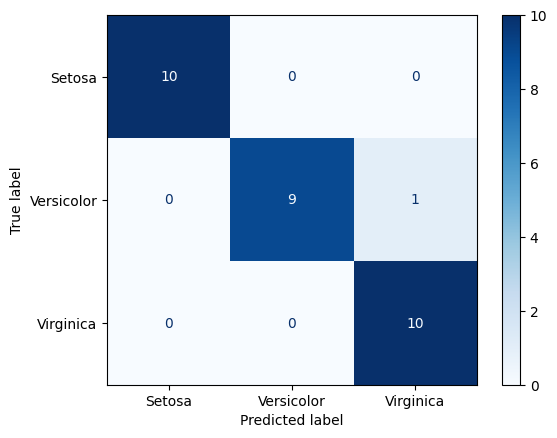

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = ovo.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Setosa", "Versicolor", "Virginica"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Visualizing the results

In [27]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary_ovo(X_scaled, y, ovo, feature_idx=(2, 3),
                                feature_names=None, resolution=0.02):
    X_2d = X_scaled[:, feature_idx]

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    # Build full-feature grid, hold non-plotted features at their mean
    grid_full = np.tile(X_scaled.mean(axis=0), (xx.ravel().shape[0], 1))
    grid_full[:, feature_idx[0]] = xx.ravel()
    grid_full[:, feature_idx[1]] = yy.ravel()

    # Use YOUR OvOClassifier's predict directly — no tuple unpacking needed
    Z = ovo.predict(grid_full).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(9, 6))
    cmap_bg  = ListedColormap(['#FFCCCC', '#CCFFCC', '#CCCCFF'])
    cmap_pts = ListedColormap(['#CC0000', '#006600', '#0000CC'])

    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8, linestyles='--')

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y,
               cmap=cmap_pts, edgecolors='k', s=55, zorder=3)

    names = feature_names or [f"Feature {feature_idx[0]}", f"Feature {feature_idx[1]}"]
    ax.set_xlabel(names[0], fontsize=12)
    ax.set_ylabel(names[1], fontsize=12)
    ax.set_title("OvO SVM — Decision Regions (2D projection)", fontsize=13)

    handles = [plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=c, markersize=9, markeredgecolor='k')
               for c in ['#CC0000', '#006600', '#0000CC']]
    ax.legend(handles, ['Setosa (0)', 'Versicolor (1)', 'Virginica (2)'], title="Species")
    plt.tight_layout()
    plt.show()

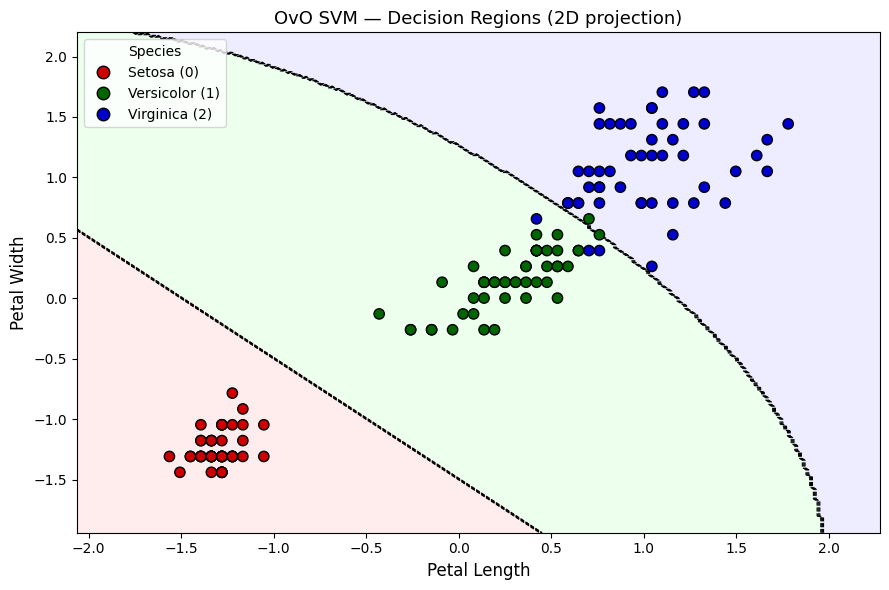

In [28]:
iris_feature_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

# models = list of (clf, label_a, label_b) — adjust to match your OvOClassifier structure
plot_decision_boundary_ovo(
    X_data.values, y_data.values, 
    ovo=ovo,           # or however you stored the 3 classifiers
    feature_idx=(2, 3),          # petal length vs petal width → clearest separation
    feature_names=iris_feature_names[2:]
)

# Comparing to Scikit-Learn Model

In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

clf = SVC()
clf.fit(X_train, y_train)

clf_pred = clf.predict(X_test_df)
clf_acc = accuracy_score(y_test_df, clf_pred)
clf_report = classification_report(y_test, clf_pred)

print(f"Accuracy: {clf_acc}\n")
print(f"Classification Report:\n {clf_report}")

Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



> Achieved comparable performance to scikit-learn model ✔

# Thank You!

<div style="background-color:#D0FF1D; padding:20px; border-radius: 8px; color: #000; text-decoration: none;">
    <div style="font-weight: 700; font-size: 38px; text-align: center;">Machine Learning Algorithms From Scratch</div>
    <a href="https://www.kaggle.com/code/aakcodebreaker/linear-regression-from-scratch" style="color:#000; text-decoration:underline; font-size: 26px">1. Linear Regression</a>
    <br>
    <a href="https://www.kaggle.com/code/aakcodebreaker/logistic-regression-from-scratch" style="color:#000; text-decoration: underline; font-size: 26px;">2. Logistic Regression</a>
    <br>
    <a href="https://www.kaggle.com/code/aakcodebreaker/svm-classification-from-scratch" style="color:#000; text-decoration: underline; font-size: 26px;">3. SVM Classification</a>
</div>